# 02 — Exploratory Data Analysis: Revenue Trends

**Project:** E-Commerce Customer & Revenue Analytics

**Business question this notebook contributes to:** What is driving revenue performance, and where should the company focus to improve revenue growth?

**Purpose of this notebook:** using the validated `fact_sales_completed` table from `01_data_cleaning_validation.ipynb`, explore how revenue is trending over time and where it comes from. Specifically:

1. Monthly revenue trend
2. Month-over-month (MoM) revenue growth
3. Monthly order volume
4. Average order value (AOV)
5. Revenue by product category
6. Revenue by region (country)
7. New vs. returning customers per month
8. Repeat purchase rate
9. Summary of observations (charts saved to `reports/figures/`)

**Input:** `data/processed/fact_sales_completed.csv` — the cleaned, Completed-only, order-line-grain fact table built and validated in `01_data_cleaning_validation.ipynb`. This notebook does not re-clean or re-derive that table; it treats it as the trusted source of truth.

**Note on scope:** customer lifetime revenue, purchase frequency, and revenue concentration (Pareto) are covered in more depth in `03_rfm_segmentation.ipynb`, since RFM's Frequency and Monetary components are the same underlying measures. This notebook focuses on time-trend and category/region cuts, plus a first look at new-vs-returning behavior.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

fact_sales = pd.read_csv(
    DATA_PROCESSED / "fact_sales_completed.csv",
    parse_dates=["order_date", "order_month", "signup_date"],
)
print("fact_sales_completed shape:", fact_sales.shape)
print("date range:", fact_sales["order_date"].min().date(), "to", fact_sales["order_date"].max().date())
fact_sales.head()

fact_sales_completed shape: (1625, 16)
date range: 2024-01-01 to 2024-12-30


,order_item_id,order_id,order_date,order_month,order_year,status,is_completed,customer_id,country,signup_date,product_id,product_name,category,quantity,price,revenue
0,2,290,2024-08-26,2024-08-01,2024,Completed,True,256,Germany,2023-06-03,18,Product_18,Makeup,2,93,186
1,3,295,2024-06-25,2024-06-01,2024,Completed,True,54,Morocco,2023-06-12,16,Product_16,Makeup,2,27,54
2,4,451,2024-04-22,2024-04-01,2024,Completed,True,152,Morocco,2023-09-15,39,Product_39,Hair,2,54,108
3,5,904,2024-10-08,2024-10-01,2024,Completed,True,159,France,2023-02-07,4,Product_4,Body,4,117,468
4,6,215,2024-12-04,2024-12-01,2024,Completed,True,60,Spain,2024-04-15,25,Product_25,Hair,2,100,200


## 1. Monthly revenue trend

,revenue
order_month,
2024-01-01,30948
2024-02-01,23299
2024-03-01,27014
2024-04-01,27839
2024-05-01,22961
2024-06-01,22819
2024-07-01,24119
2024-08-01,27371
2024-09-01,23332


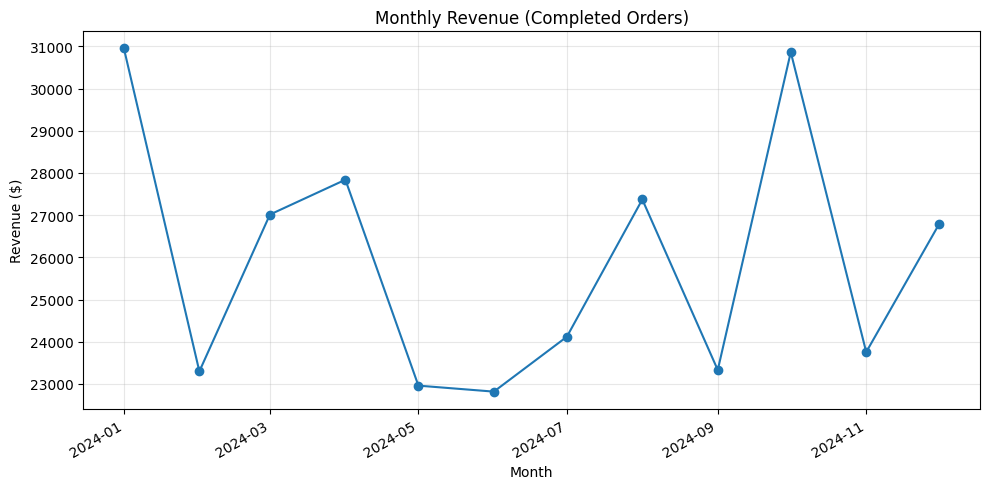

In [13]:
monthly_revenue = fact_sales.groupby("order_month")["revenue"].sum().sort_index()
display(monthly_revenue.to_frame("revenue"))

fig, ax = plt.subplots()
ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="#1f77b4")
ax.set_title("Monthly Revenue (Completed Orders)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "01_monthly_revenue.png", dpi=150)
plt.show()

## 2. Month-over-month revenue growth

,mom_growth_%
order_month,
2024-01-01,NaN
2024-02-01,-24.7
2024-03-01,15.9
2024-04-01,3.1
2024-05-01,-17.5
2024-06-01,-0.6
2024-07-01,5.7
2024-08-01,13.5
2024-09-01,-14.8


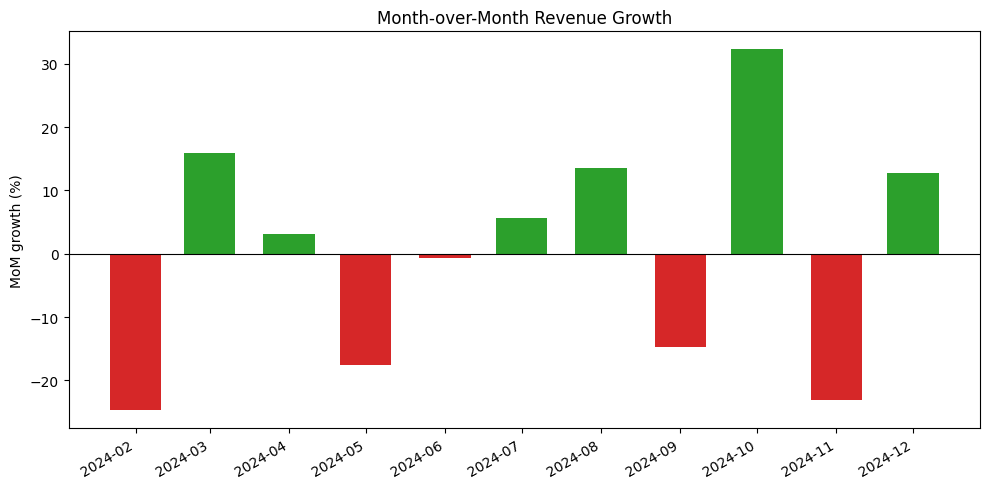

Average MoM growth (excl. first month): 0.2 %
Best month: 2024-10 (32.3%)
Worst month: 2024-02 (-24.7%)


In [14]:
mom_growth = monthly_revenue.pct_change() * 100
display(mom_growth.round(1).to_frame("mom_growth_%"))

colors = ["#2ca02c" if v >= 0 else "#d62728" for v in mom_growth.fillna(0)]
fig, ax = plt.subplots()
ax.bar(mom_growth.index, mom_growth.values, width=20, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-Month Revenue Growth")
ax.set_ylabel("MoM growth (%)")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "02_mom_growth.png", dpi=150)
plt.show()

print("Average MoM growth (excl. first month):", round(mom_growth.mean(), 1), "%")
print("Best month:", mom_growth.idxmax().strftime("%Y-%m"), f"({mom_growth.max():.1f}%)")
print("Worst month:", mom_growth.idxmin().strftime("%Y-%m"), f"({mom_growth.min():.1f}%)")

## 3. Monthly order volume

Counting **distinct `order_id`**, not line items — an order with 3 products should count once, not three times.

,distinct_orders
order_month,
2024-01-01,69
2024-02-01,47
2024-03-01,65
2024-04-01,57
2024-05-01,51
2024-06-01,55
2024-07-01,42
2024-08-01,66
2024-09-01,58


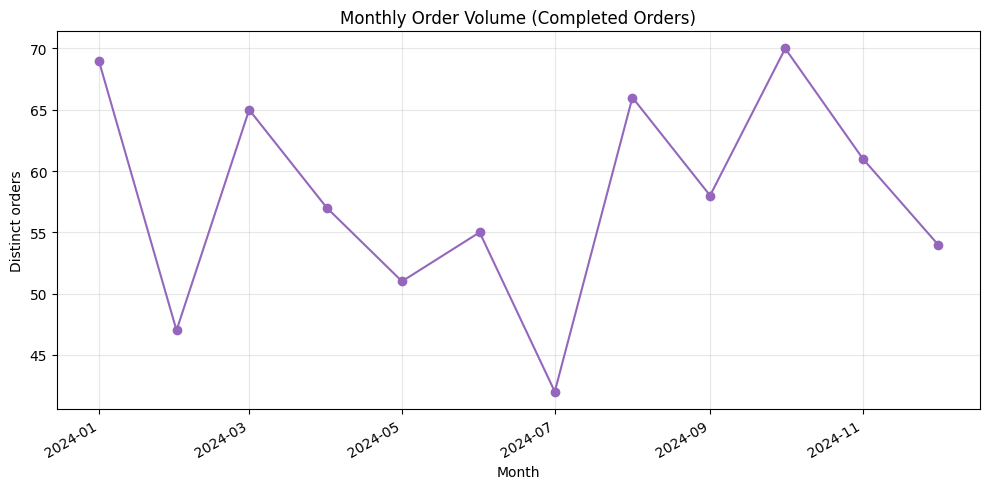

In [15]:
monthly_orders = fact_sales.groupby("order_month")["order_id"].nunique().sort_index()
display(monthly_orders.to_frame("distinct_orders"))

fig, ax = plt.subplots()
ax.plot(monthly_orders.index, monthly_orders.values, marker="o", color="#9467bd")
ax.set_title("Monthly Order Volume (Completed Orders)")
ax.set_xlabel("Month")
ax.set_ylabel("Distinct orders")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "03_monthly_orders.png", dpi=150)
plt.show()

## 4. Average order value (AOV)

AOV = monthly revenue ÷ monthly distinct orders. Shown alongside revenue and order volume so it's clear whether revenue changes are driven by *more orders* or *bigger orders*.

,aov
order_month,
2024-01-01,448.52
2024-02-01,495.72
2024-03-01,415.60
2024-04-01,488.40
2024-05-01,450.22
2024-06-01,414.89
2024-07-01,574.26
2024-08-01,414.71
2024-09-01,402.28


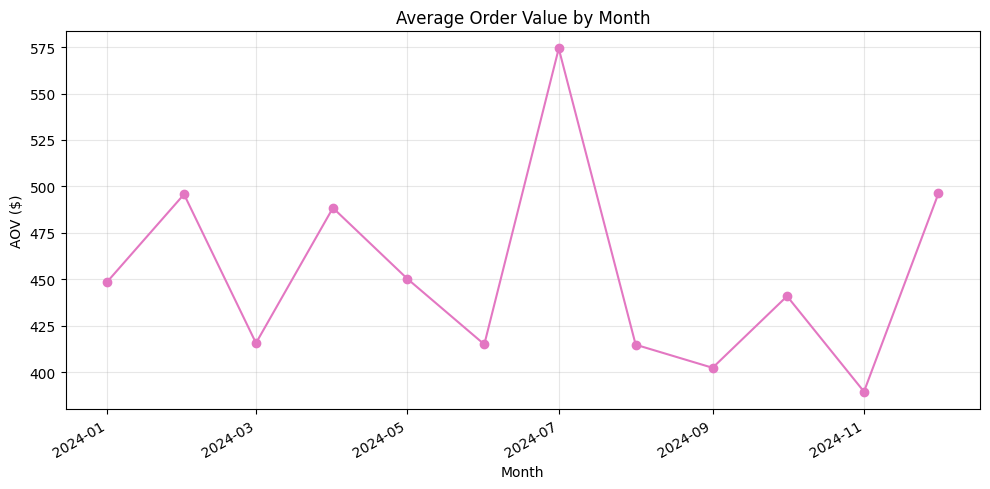

Overall AOV (full period): $447.64


In [18]:
aov = (monthly_revenue / monthly_orders).rename("aov")
display(aov.round(2).to_frame())

fig, ax = plt.subplots()
ax.plot(aov.index, aov.values, marker="o", color="#e377c2")
ax.set_title("Average Order Value by Month")
ax.set_xlabel("Month")
ax.set_ylabel("AOV ($)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "04_aov.png", dpi=150)
plt.show()

overall_aov = fact_sales["revenue"].sum() / fact_sales["order_id"].nunique()
print(f"Overall AOV (full period): ${overall_aov:,.2f}")

## 5. Revenue by product category

,revenue,share_%
category,,
Hair,101637,32.7
Makeup,81085,26.1
Body,76011,24.4
Skin,52378,16.8


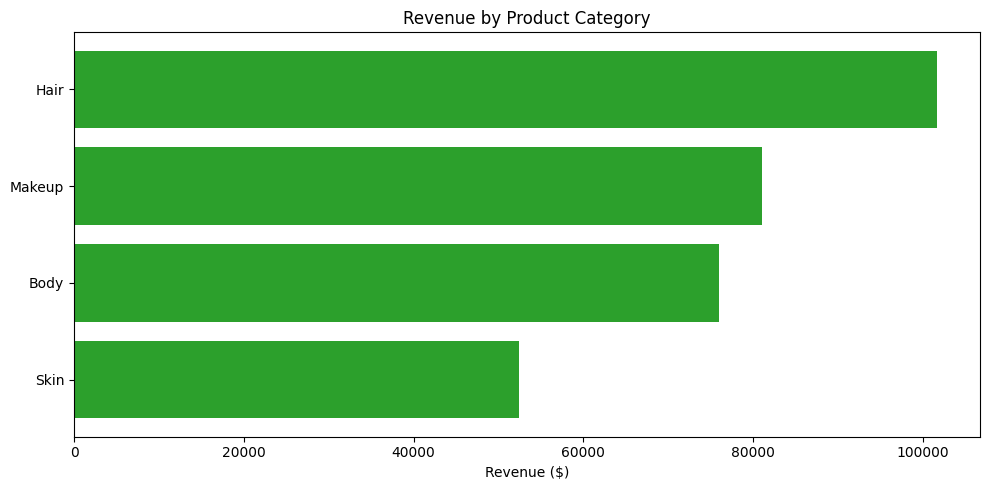

In [19]:
category_revenue = fact_sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
category_share = (category_revenue / category_revenue.sum() * 100).round(1)
display(pd.DataFrame({"revenue": category_revenue, "share_%": category_share}))

fig, ax = plt.subplots()
ax.barh(category_revenue.index[::-1], category_revenue.values[::-1], color="#2ca02c")
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Revenue ($)")
fig.tight_layout()
fig.savefig(FIGURES / "05_revenue_by_category.png", dpi=150)
plt.show()

## 6. Revenue by region (country)

,revenue,share_%
country,,
Italy,70719,22.7
Spain,69897,22.5
Morocco,65164,20.9
France,55976,18.0
Germany,49355,15.9


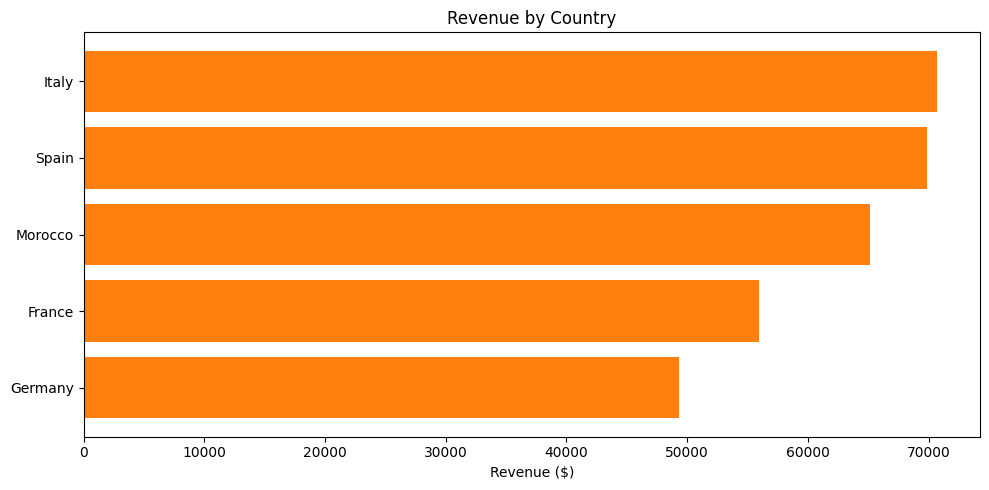

In [20]:
country_revenue = fact_sales.groupby("country")["revenue"].sum().sort_values(ascending=False)
country_share = (country_revenue / country_revenue.sum() * 100).round(1)
display(pd.DataFrame({"revenue": country_revenue, "share_%": country_share}))

fig, ax = plt.subplots()
ax.barh(country_revenue.index[::-1], country_revenue.values[::-1], color="#ff7f0e")
ax.set_title("Revenue by Country")
ax.set_xlabel("Revenue ($)")
fig.tight_layout()
fig.savefig(FIGURES / "06_revenue_by_country.png", dpi=150)
plt.show()

## 7. New vs. returning customers per month

**Definition used here:** a customer's "first purchase month" is the earliest `order_month` in which they have a **Completed** order — not their `signup_date`. Section 5 of `notebooks/01` found 55 orders placed before the customer's recorded `signup_date`, so `signup_date` isn't a fully reliable acquisition marker in this dataset. First completed purchase month is used consistently here and in `04_cohort_retention.ipynb`.

A customer is **New** in a given month if that month *is* their first purchase month, and **Returning** in every month after that.

customer_type,New,Returning
order_month,,
2024-01-01,30948,0
2024-02-01,19111,4188
2024-03-01,18918,8096
2024-04-01,14182,13657
2024-05-01,11444,11517
2024-06-01,9564,13255
2024-07-01,8395,15724
2024-08-01,5739,21632
2024-09-01,5531,17801


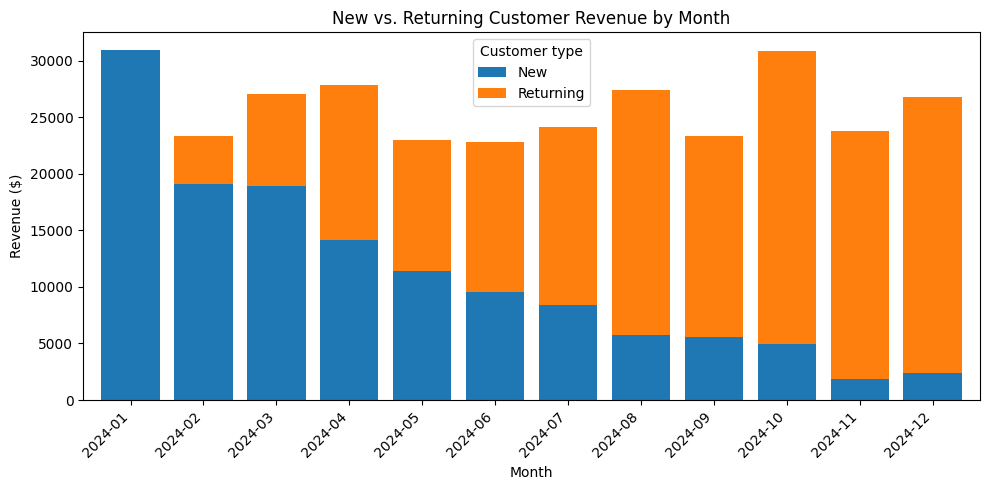

Returning-customer share of revenue, by month:
order_month
2024-01-01     0.0
2024-02-01    18.0
2024-03-01    30.0
2024-04-01    49.1
2024-05-01    50.2
2024-06-01    58.1
2024-07-01    65.2
2024-08-01    79.0
2024-09-01    76.3
2024-10-01    84.0
2024-11-01    92.1
2024-12-01    91.2
dtype: float64


In [21]:
first_purchase_month = fact_sales.groupby("customer_id")["order_month"].min().rename("first_purchase_month")
fact_sales = fact_sales.merge(first_purchase_month, on="customer_id", how="left")
fact_sales["customer_type"] = np.where(
    fact_sales["order_month"] == fact_sales["first_purchase_month"], "New", "Returning"
)

monthly_type_revenue = (
    fact_sales.groupby(["order_month", "customer_type"])["revenue"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)
monthly_type_revenue = monthly_type_revenue[[c for c in ["New", "Returning"] if c in monthly_type_revenue.columns]]
display(monthly_type_revenue)

fig, ax = plt.subplots()
monthly_type_revenue.plot(kind="bar", stacked=True, ax=ax, color=["#1f77b4", "#ff7f0e"], width=0.8)
ax.set_title("New vs. Returning Customer Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_type_revenue.index], rotation=45, ha="right")
ax.legend(title="Customer type")
fig.tight_layout()
fig.savefig(FIGURES / "07_new_vs_returning.png", dpi=150)
plt.show()

returning_share = (monthly_type_revenue["Returning"] / monthly_type_revenue.sum(axis=1) * 100).round(1)
print("Returning-customer share of revenue, by month:")
print(returning_share)

## 8. Repeat purchase rate

In [22]:
orders_per_customer = fact_sales.groupby("customer_id")["order_id"].nunique()

total_customers = orders_per_customer.shape[0]
repeat_customers = int((orders_per_customer > 1).sum())
repeat_rate = repeat_customers / total_customers * 100

print(f"Customers with a Completed order in this dataset: {total_customers}")
print(f"Customers with >= 2 Completed orders (repeat buyers): {repeat_customers} ({repeat_rate:.1f}%)")
print(f"Average completed orders per customer: {orders_per_customer.mean():.2f}")

print("\nDistribution of completed orders per customer:")
display(orders_per_customer.value_counts().sort_index().to_frame("num_customers"))

Customers with a Completed order in this dataset: 267
Customers with >= 2 Completed orders (repeat buyers): 196 (73.4%)
Average completed orders per customer: 2.60

Distribution of completed orders per customer:


,num_customers
order_id,
1,71
2,75
3,57
4,35
5,17
6,8
7,2
8,2


## 9. Summary of observations

- **Revenue trend:** revenue is essentially **flat across 2024**, not clearly growing or declining — it ranges from $22.8K (June) to $30.9K (January/October), with an average MoM growth of only +0.2%. There's no sustained upward or downward trend; the swings look like month-to-month noise rather than a structural change (best month Oct 2024 at +32.3% MoM, worst Feb 2024 at -24.7% MoM).
- **Volume vs. AOV:** revenue swings track **order volume** (42–70 orders/month) much more closely than AOV, which stays in a fairly tight $390–$500 band for 11 of 12 months (July is the one outlier at $574, on a low order count of 42). In other words, when a month's revenue is up or down, it's mostly because more or fewer orders were placed — not because customers bought bigger baskets.
- **Category concentration:** revenue is reasonably balanced across the 4 categories — Hair leads at 32.7% ($101,637), followed by Makeup 26.1%, Body 24.4%, and Skin 16.8%. No single category dominates, so category-level risk is low.
- **Regional concentration:** even more balanced — the 5 countries range from Italy's 22.7% down to Germany's 15.9%, a spread of under 7 points. No single market the business is overexposed to.
- **New vs. returning — the most important finding in this notebook:** returning customers' *share* of revenue climbs steadily all year, from 0% in January to 92% by November. Some of that is mechanical (month 1 can only be "new" by definition), but the more telling number is the **absolute dollar trend**: new-customer revenue falls almost every month, from $30,948 in January to just $1,883–$2,362 in November/December — while total revenue stays flat because returning-customer spend grows to offset it. That means flat overall revenue in 2024 is currently being propped up by an existing customer base, not by acquiring new ones, which is a risk if that pool of repeat buyers ever plateaus.
- **Repeat purchase rate:** strong — 73.4% of the 267 customers who completed at least one order placed 2 or more (196 customers), averaging 2.60 completed orders each. Retention behavior itself looks healthy; the concern above is specifically about the *inflow* of new customers, not repeat behavior.

These observations feed into `reports/findings.md` (business recommendations) alongside the RFM, cohort, and product-performance notebooks.